In [1]:
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

In [2]:
# suprafete vs pret
apartamente = np.array([ (30, 54_000), (36, 75_000), (49, 120_000), (53, 175_000),  (69, 193_000), (70, 215_000) , (79, 210_000), (83, 245_000), (84, 284_000), (90, 345_000) ])
suprafete = apartamente[:, 0]
preturi = apartamente[:, 1]

In [3]:
x = suprafete
y = preturi
n = len(x)
n

10

In [4]:
x_mean = np.mean(x)
y_mean = np.mean(y)

print("x_mean:", x_mean, "y_mean:", y_mean)

x_mean: 64.3 y_mean: 191600.0


# Solutia 1 - folosind derivatele partile ale lui a si b (setandu-le la 0)

In [5]:
a_analitic = np.sum((x - x_mean) * (y - y_mean)) / np.sum((x-x_mean) ** 2)
a_analitic 

np.float64(4110.226790748734)

In [6]:
b_analitic = y_mean - a_analitic * x_mean
b_analitic

np.float64(-72687.58264514356)

# Solutie comparativa (scipy) 

In [7]:
result = stats.linregress(x, y)
a_scipy = result.slope
b_scipy = result.intercept

In [8]:
print("scipy:", a_scipy, b_scipy)
print("analitic:", a_analitic, b_analitic)

scipy: 4110.226790748733 -72687.5826451435
analitic: 4110.226790748734 -72687.58264514356


# Solutie 2 - calculând folosind Gradient Descend

### 1. Normalizăm datele

In [9]:
x, y

(array([30, 36, 49, 53, 69, 70, 79, 83, 84, 90]),
 array([ 54000,  75000, 120000, 175000, 193000, 215000, 210000, 245000,
        284000, 345000]))

In [10]:
x_std = np.std(x)
y_std = np.std(y)

x_norm = (x - x_mean) / x_std
y_norm = (y - y_mean) / y_std

x_norm, y_norm



(array([-1.7132662 , -1.41356948, -0.76422661, -0.5644288 ,  0.23476242,
         0.28471188,  0.73425694,  0.93405475,  0.9840042 ,  1.28370091]),
 array([-1.60238064, -1.35783127, -0.8337969 , -0.19331046,  0.01630329,
         0.27249787,  0.21427183,  0.62185411,  1.07601723,  1.78637493]))

# 2. Initializarea pasilor

In [11]:
a_gd = 0
b_gd = 0
alpha = 0.1  # De obicei sunt valori puteri ale lui 10 ( 0.1, 0.01, 0.001, 1, 10, 100)
epochs = 1000 # (Cate rulari trebuie sa existe)


## Calculul gradientilor

In [12]:
y_pred = a_gd * x_norm + b_gd

errros = y_pred - y_norm

errros


array([ 1.60238064,  1.35783127,  0.8337969 ,  0.19331046, -0.01630329,
       -0.27249787, -0.21427183, -0.62185411, -1.07601723, -1.78637493])

In [13]:
grad_a = (2/n) * np.sum(errros * x_norm)
grad_b = (2/n) * np.sum(errros)

grad_a, grad_b

(np.float64(-1.916515389740441), np.float64(8.881784197001253e-17))

In [14]:
# Noul a
a_gd = a_gd - alpha * grad_a

## Noul b
b_gd = b_gd - alpha * grad_b

# Repetăm pașii de 1000 de ori (câte epoci avem)

In [15]:
a_gd = 0
b_gd = 0
alpha = 0.1  # De obicei sunt valori puteri ale lui 10 ( 0.1, 0.01, 0.001, 1, 10, 100)
epochs = 1000 # (Cate rulari trebuie sa existe) -> de incercat si cu 10, 100, 10_000, 100_000
history = []

for i in range(epochs):
    y_pred = a_gd * x_norm + b_gd
    errros = y_pred - y_norm
    grad_a = (2/n) * np.sum(errros * x_norm)
    grad_b = (2/n) * np.sum(errros)
    
    a_gd = a_gd - alpha * grad_a
    ## Noul b
    b_gd = b_gd - alpha * grad_b

print(f"La finalul celor {epochs} epoci a = {a_gd} b = {b_gd}")


La finalul celor 1000 epoci a = 0.9582576948702202 b = -1.1102230246251565e-16


In [16]:
a_from_gd = a_gd * (y_std / x_std)
b_from_gd = y_mean + b_gd * y_std - a_from_gd * x_mean
a_from_gd, b_from_gd

(np.float64(4110.226790748733), np.float64(-72687.5826451435))

In [17]:
# (np.float64(4110.226790748733), np.float64(-72687.5826451435))

# Vizualizarea rezultatelor

In [18]:
def linear_plot(x, y, a, b):
    plt.scatter(x, y);
    plt.plot(x, a * x + b);
    plt.xlabel("Suprafere");
    plt.ylabel("Preturi");
    plt.show();

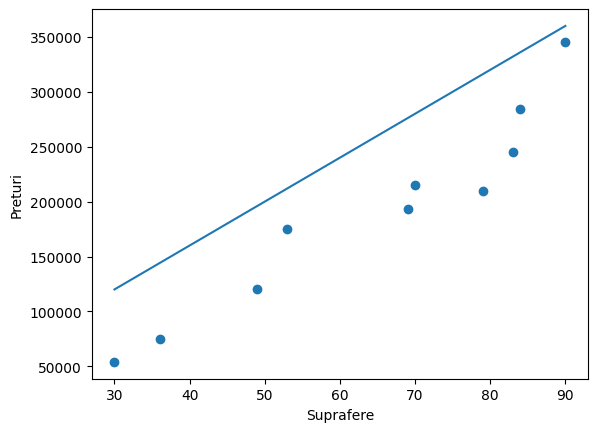

In [19]:
linear_plot(suprafete, preturi, 4000, 0);

In [20]:
def linear_plot(x, y, a, b):
    plt.scatter(x, y);
    plt.plot(x, a * x + b);
    plt.xlabel("Suprafere");
    plt.ylabel("Preturi");
    plt.show();

In [21]:
def to_real(a_gd, b_gd):
    a_from_gd = a_gd * (y_std / x_std)
    b_from_gd = y_mean + b_gd * y_std - a_from_gd * x_mean
    return a_from_gd, b_from_gd

In [51]:
a_gd = 0
b_gd = 0
alpha = 0.1  # De obicei sunt valori puteri ale lui 10 ( 0.1, 0.01, 0.001, 1, 10, 100)
epochs = 1000 # (Cate rulari trebuie sa existe) -> de incercat si cu 10, 100, 10_000, 100_000
history = []

def ruleza_o_epoca():
    global a_gd, b_gd
    y_pred = a_gd * x_norm + b_gd
    errros = y_pred - y_norm
    grad_a = (2/n) * np.sum(errros * x_norm)
    grad_b = (2/n) * np.sum(errros)
    
    a_gd = a_gd - alpha * grad_a
    ## Noul b
    b_gd = b_gd - alpha * grad_b

    ## Crearea elementelor initiale
    a_real, b_real = to_real(a_gd, b_gd)
    linear_plot(suprafete, preturi, a_real, b_real)

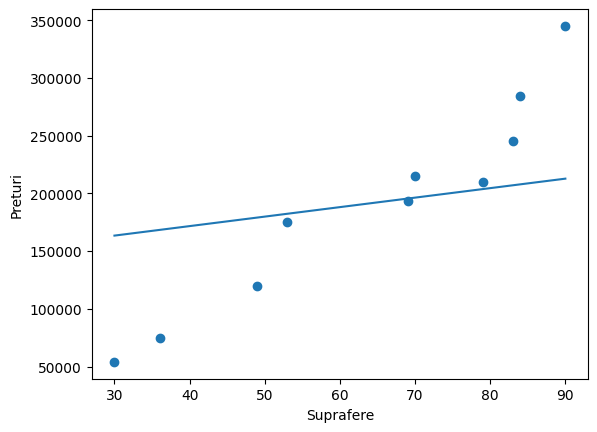

In [52]:
ruleza_o_epoca()

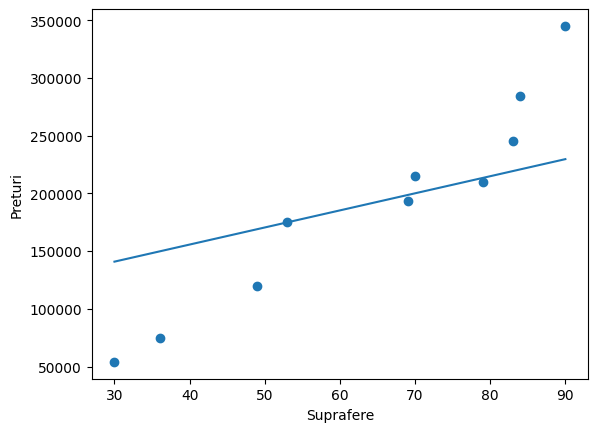

In [53]:
ruleza_o_epoca()

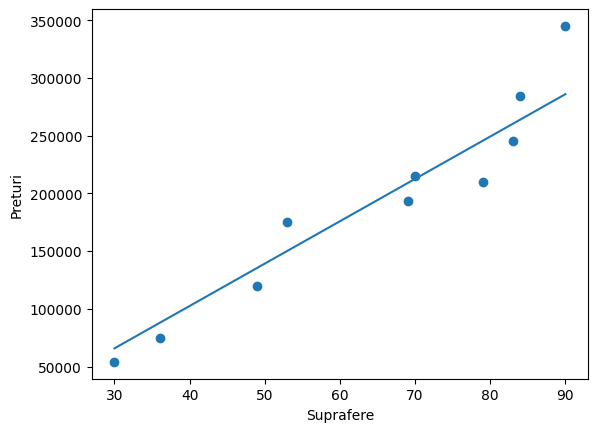

In [61]:
ruleza_o_epoca()

# Animatia epocilor

In [63]:
import time
from IPython.display import clear_output

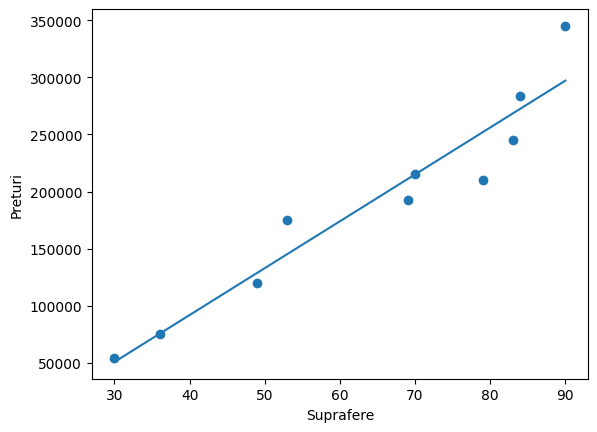

In [69]:
a_gd = 0
b_gd = 0
alpha = 0.1  # De obicei sunt valori puteri ale lui 10 ( 0.1, 0.01, 0.001, 1, 10, 100)
epochs = 30 # (Cate rulari trebuie sa existe) -> de incercat si cu 10, 100, 10_000, 100_000



for i in range(epochs):
    clear_output(wait=True)

    ruleza_o_epoca()

    time.sleep(0.5)

